In [1]:
!conda install -c conda-forge awswrangler -y 

Retrieving notices: done
Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.11.0
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /home/ec2-user/anaconda3/envs/python3

  added / updated specs:
    - awswrangler


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    aws-c-auth-0.10.1          |       h2d2dd48_2         131 KB  conda-forge
    aws-c-event-stream-0.6.0   |       h9b893ba_1          58 KB  conda-forge
    aws-c-http-0.10.12         |       h4bacb7b_1         221 KB  conda-forge
    aws-c-io-0.26.3            |       hc87160b_0         177 KB  conda-forge
    aws-c-mqtt-0.15.2          |       he9ea9c5_1         217 KB  conda-forge
    aws-c-s3-0.11.5            |       h6d69fc9_5  

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
# ============================================================================
# FIND OPTIMAL K - ELBOW METHOD & CENTROID TESTING
# ============================================================================
# 
# Run this BEFORE the main clustering notebook to determine optimal k
# Uses weighted clustering throughout
#
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import awswrangler as wr

def query_athena(query, database='nfl_data'):
    """Execute Athena query and return DataFrame"""
    df = wr.athena.read_sql_query(
        sql=query,
        database=database,
        ctas_approach=False
    )
    return df

In [5]:
# ============================================================================
# LOAD DATA
# ============================================================================

query_tgt_rte = """
SELECT  agg.*,
        CASE WHEN routes < 35 THEN 0 ELSE 1 END AS route_ind,
        CASE WHEN targets < 9 THEN 0 ELSE 1 END AS target_ind
FROM    nfl_data.vw_receiving_depth_weekly_agg agg
"""

print("Querying Athena...")
df_tgt_rte = query_athena(query_tgt_rte)
print(f"Loaded {len(df_tgt_rte):,} player-seasons")

Querying Athena...
Loaded 6,256 player-seasons


In [6]:
# ============================================================================
# FEATURE ENGINEERING
# ============================================================================

# Route rates
df_tgt_rte['deep_rte_rate'] = (df_tgt_rte['deep_routes'] / df_tgt_rte['routes'] * 100).round(1)
df_tgt_rte['medium_rte_rate'] = (df_tgt_rte['medium_routes'] / df_tgt_rte['routes'] * 100).round(1)
df_tgt_rte['short_rte_rate'] = (df_tgt_rte['short_routes'] / df_tgt_rte['routes'] * 100).round(1)
df_tgt_rte['behind_los_rte_rate'] = (df_tgt_rte['behind_los_routes'] / df_tgt_rte['routes'] * 100).round(1)

features_rte = ['deep_rte_rate', 'medium_rte_rate', 'short_rte_rate', 'behind_los_rte_rate']

In [7]:
# Target rates
df_tgt_rte['deep_tgt_rate'] = (df_tgt_rte['deep_targets'] / df_tgt_rte['targets'] * 100).round(1)
df_tgt_rte['medium_tgt_rate'] = (df_tgt_rte['medium_targets'] / df_tgt_rte['targets'] * 100).round(1)
df_tgt_rte['short_tgt_rate'] = (df_tgt_rte['short_targets'] / df_tgt_rte['targets'] * 100).round(1)
df_tgt_rte['behind_los_tgt_rate'] = (df_tgt_rte['behind_los_targets'] / df_tgt_rte['targets'] * 100).round(1)

features_tgt = ['deep_tgt_rate', 'medium_tgt_rate', 'short_tgt_rate', 'behind_los_tgt_rate']

In [8]:
# Filter
df_rte_filtered = df_tgt_rte[df_tgt_rte['route_ind'] == 1].copy()
df_tgt_filtered = df_tgt_rte[df_tgt_rte['target_ind'] == 1].copy()

print(f"\nFiltered to {len(df_rte_filtered):,} player-seasons for routes")
print(f"Filtered to {len(df_tgt_filtered):,} player-seasons for targets")


Filtered to 3,800 player-seasons for routes
Filtered to 3,430 player-seasons for targets


In [14]:
# Prepare clustering data with WEIGHTS
X_rte_values = df_rte_filtered[features_rte].values
weights_route = np.sqrt(df_rte_filtered['routes'].values)

X_tgt_values = df_tgt_filtered[features_tgt].values
weights_target = np.sqrt(df_tgt_filtered['targets'].values)

print(f"\nRoute weights range: {weights_route.min():.1f} to {weights_route.max():.1f}")
print(f"Target weights range: {weights_target.min():.1f} to {weights_target.max():.1f}")


Route weights range: 5.9 to 26.4
Target weights range: 3.0 to 15.2


In [15]:
# ============================================================================
# ELBOW METHOD FUNCTION
# ============================================================================

def run_elbow_analysis(X, weights, title, k_range=range(3, 13)):
    """Run elbow method with weighted KMeans"""
    
    print(f"\n{'='*80}")
    print(f"ELBOW ANALYSIS: {title}")
    print(f"{'='*80}")
    
    inertias = []
    silhouette_scores = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, n_init=25, random_state=42)
        kmeans.fit(X, sample_weight=weights)
        inertias.append(kmeans.inertia_)
        
        labels = kmeans.labels_
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        
        print(f"k={k}: Inertia={kmeans.inertia_:,.0f}, Silhouette={score:.3f}")
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(k_range, inertias, 'bo-')
    ax1.set_xlabel('Number of clusters (k)')
    ax1.set_ylabel('Inertia')
    ax1.set_title(f'{title}: Inertia vs k')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(k_range, silhouette_scores, 'ro-')
    ax2.set_xlabel('Number of clusters (k)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title(f'{title}: Silhouette Score vs k')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return inertias, silhouette_scores

In [16]:
# ============================================================================
# TEST SPECIFIC K VALUE
# ============================================================================

def test_k_value(X, weights, features, k, title_prefix):
    """Test a specific k value and show clean visualization with WEIGHTS"""
    
    # Run clustering WITH WEIGHTS
    kmeans = KMeans(n_clusters=k, n_init=25, random_state=42)
    kmeans.fit(X, sample_weight=weights)
    
    # Calculate silhouette (no weights in sklearn)
    labels = kmeans.labels_
    sil_score = silhouette_score(X, labels)
    
    # Create centroids dataframe
    centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)
    centroids['cluster'] = range(k)
    centroids['count'] = pd.Series(labels).value_counts().sort_index().values
    centroids = centroids[['cluster', 'count'] + features]
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(12, max(6, k * 0.5)))
    sns.heatmap(
        centroids[features].T,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        cbar_kws={'label': 'Percentage %'},
        xticklabels=centroids['cluster'],
        yticklabels=features,
        ax=ax,
        linewidths=0.5
    )
    ax.set_title(f'{title_prefix} | k={k} | Silhouette={sil_score:.3f} | Inertia={kmeans.inertia_:,.0f}', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*80}")
    print(f"{title_prefix} | k={k}")
    print(f"{'='*80}")
    print(centroids.to_string(index=False))
    print(f"\nSilhouette: {sil_score:.3f} | Inertia: {kmeans.inertia_:,.0f}")
    
    return kmeans, centroids, sil_score


ROUTE CLUSTERING ANALYSIS

ELBOW ANALYSIS: ROUTES
k=3: Inertia=2,622,105, Silhouette=0.269
k=4: Inertia=2,270,696, Silhouette=0.233
k=5: Inertia=2,008,385, Silhouette=0.216
k=6: Inertia=1,818,021, Silhouette=0.218
k=7: Inertia=1,682,192, Silhouette=0.209
k=8: Inertia=1,548,551, Silhouette=0.214
k=9: Inertia=1,447,483, Silhouette=0.215
k=10: Inertia=1,362,824, Silhouette=0.209
k=11: Inertia=1,288,486, Silhouette=0.207
k=12: Inertia=1,228,020, Silhouette=0.205


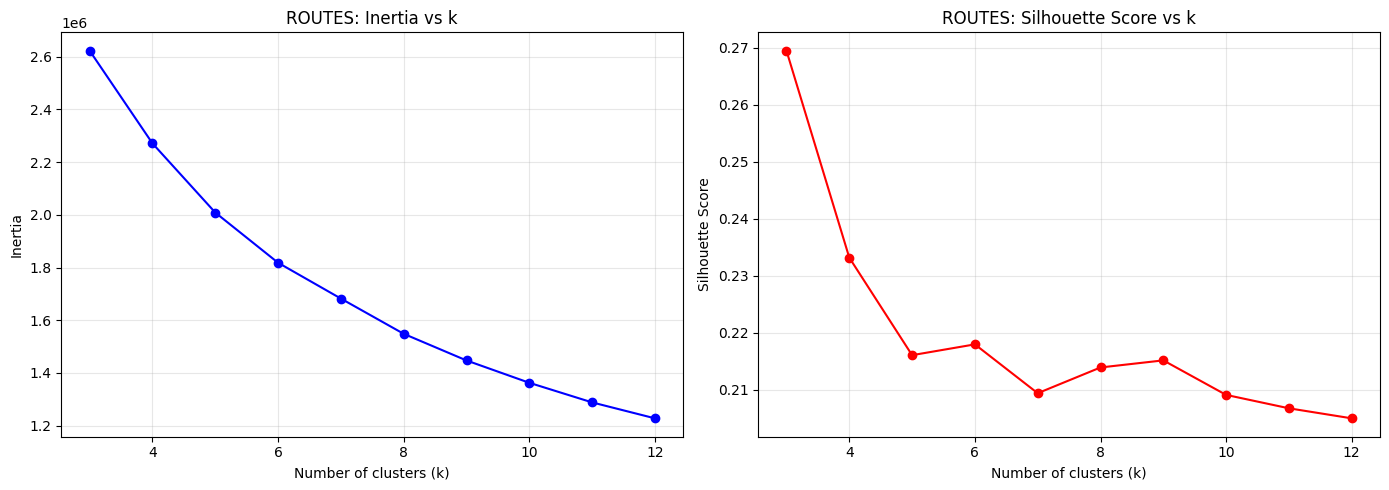

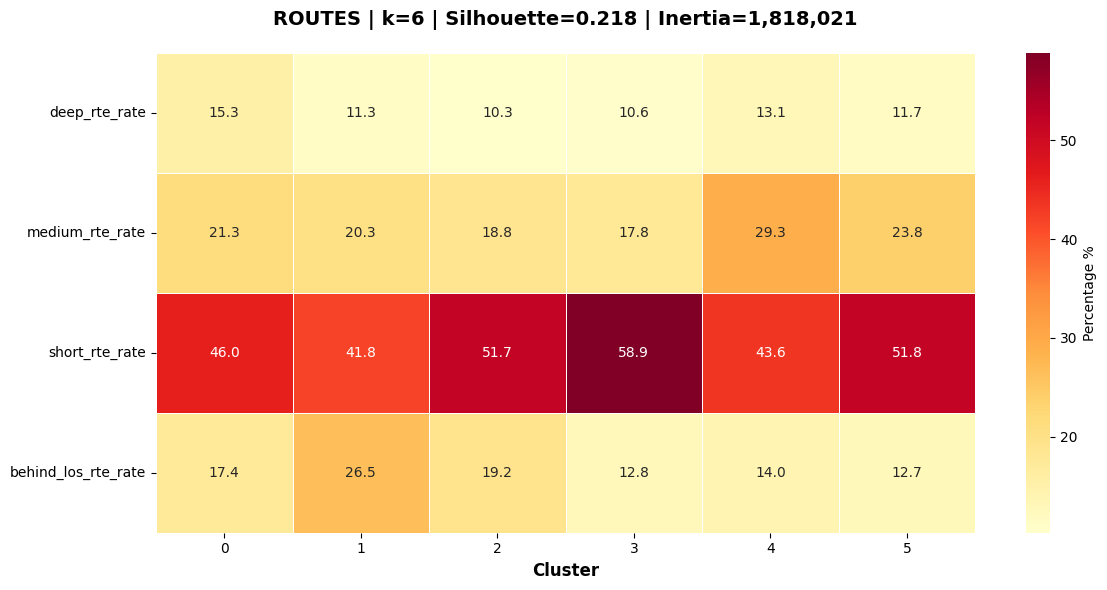


ROUTES | k=6
 cluster  count  deep_rte_rate  medium_rte_rate  short_rte_rate  behind_los_rte_rate
       0    691      15.287612        21.264913       46.008398            17.440231
       1    412      11.345424        20.303307       41.825333            26.523250
       2    789      10.297740        18.765990       51.725199            19.210844
       3    540      10.551262        17.816379       58.853706            12.777968
       4    541      13.145220        29.257241       43.616663            13.982057
       5    827      11.711505        23.788469       51.764424            12.738204

Silhouette: 0.218 | Inertia: 1,818,021


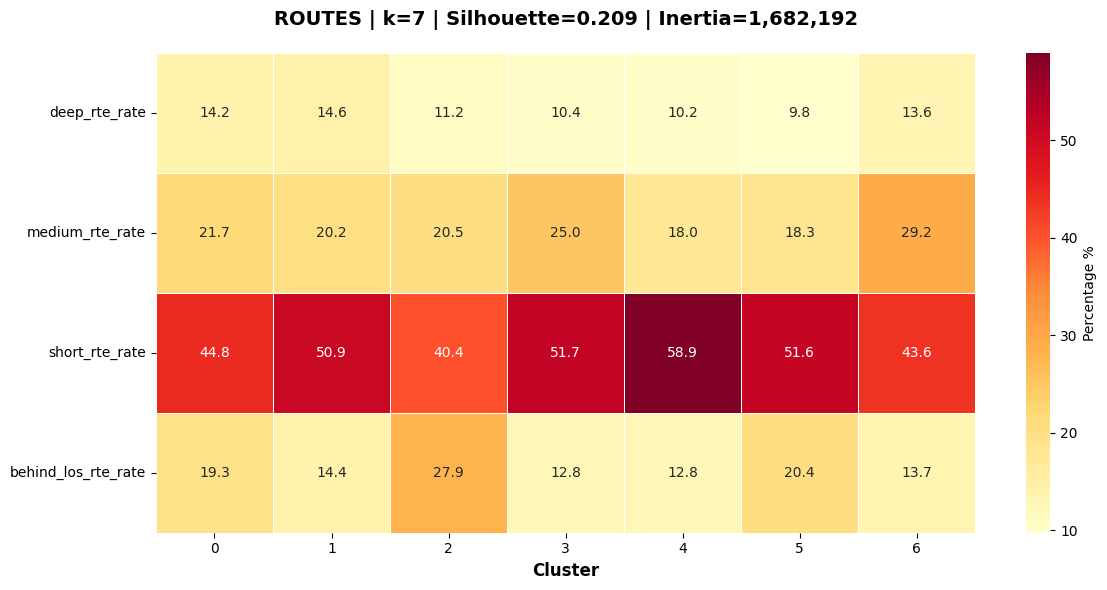


ROUTES | k=7
 cluster  count  deep_rte_rate  medium_rte_rate  short_rte_rate  behind_los_rte_rate
       0    609      14.162655        21.720562       44.827361            19.290370
       1    595      14.590768        20.178612       50.864498            14.365321
       2    295      11.178399        20.461510       40.437746            27.920517
       3    627      10.414531        25.038394       51.713160            12.835735
       4    526      10.236392        17.997134       58.940773            12.825459
       5    633       9.766509        18.273773       51.592883            20.368193
       6    515      13.595445        29.178250       43.575158            13.652779

Silhouette: 0.209 | Inertia: 1,682,192


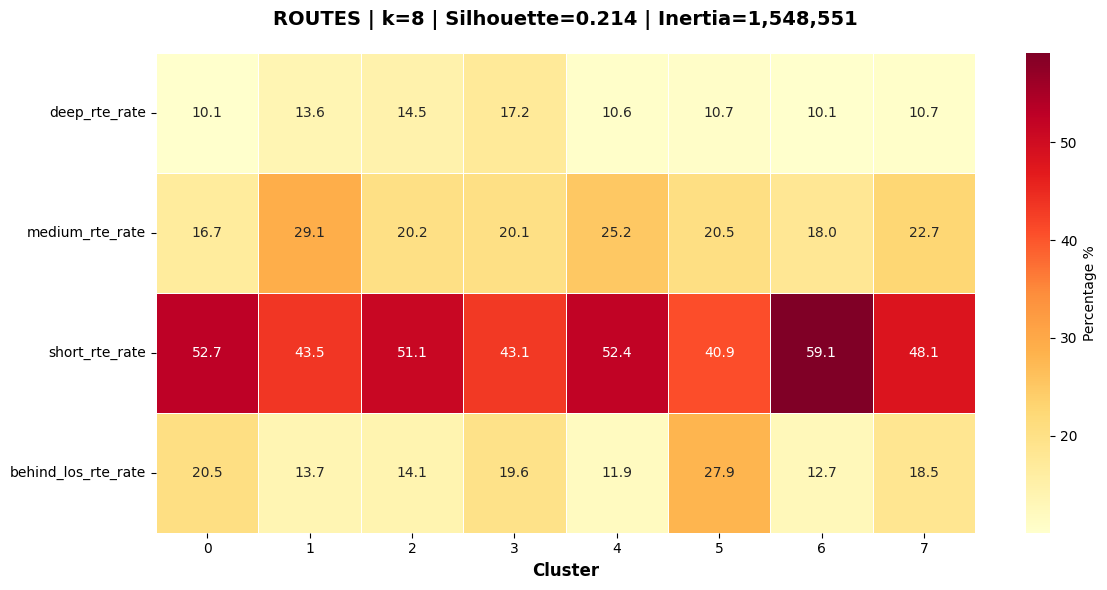


ROUTES | k=8
 cluster  count  deep_rte_rate  medium_rte_rate  short_rte_rate  behind_los_rte_rate
       0    485      10.100938        16.712732       52.723860            20.464326
       1    512      13.612419        29.118477       43.539039            13.733428
       2    553      14.542863        20.237386       51.112646            14.105653
       3    352      17.204842        20.119077       43.115388            19.555746
       4    516      10.582969        25.216349       52.350731            11.851660
       5    290      10.723546        20.459676       40.890345            27.924836
       6    479      10.120288        18.049167       59.144071            12.686462
       7    613      10.665605        22.729601       48.130373            18.477066

Silhouette: 0.214 | Inertia: 1,548,551


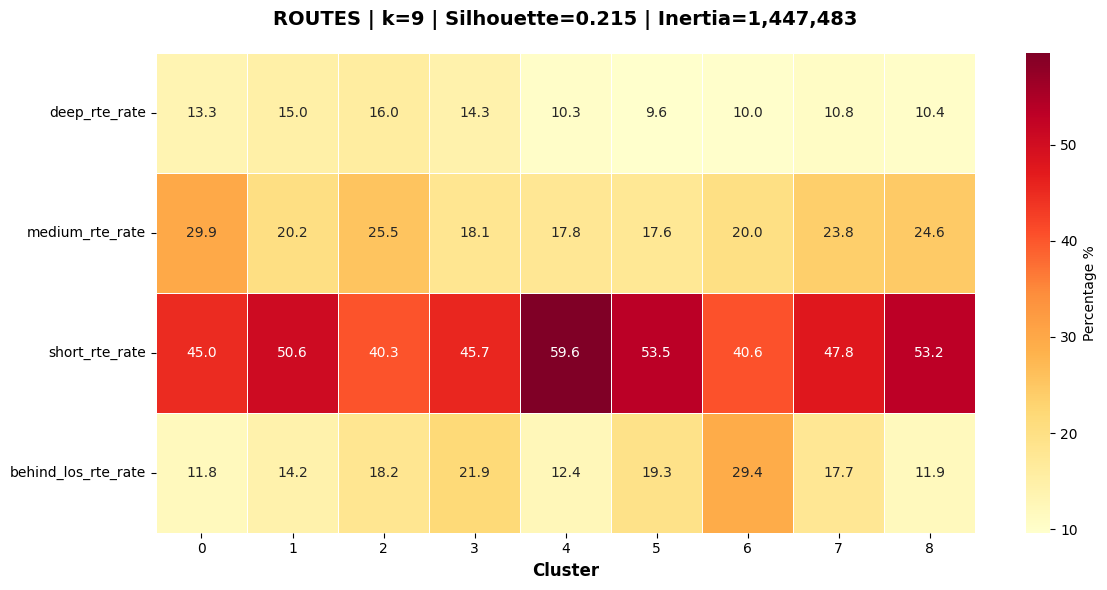


ROUTES | k=9
 cluster  count  deep_rte_rate  medium_rte_rate  short_rte_rate  behind_los_rte_rate
       0    372      13.344933        29.857353       44.988631            11.812951
       1    546      14.978384        20.201595       50.640661            14.179627
       2    296      15.981748        25.513230       40.338923            18.162343
       3    365      14.308343        18.136199       45.654494            21.897393
       4    424      10.292008        17.774330       59.557630            12.377272
       5    508       9.628184        17.571477       53.474671            19.326624
       6    221       9.970713        20.040186       40.601723            29.383149
       7    592      10.766650        23.751463       47.785719            17.699214
       8    476      10.406482        24.565144       53.178663            11.851403

Silhouette: 0.215 | Inertia: 1,447,483

TARGET CLUSTERING ANALYSIS

ELBOW ANALYSIS: TARGETS
k=3: Inertia=6,070,539, Silhouette=0.395
k=

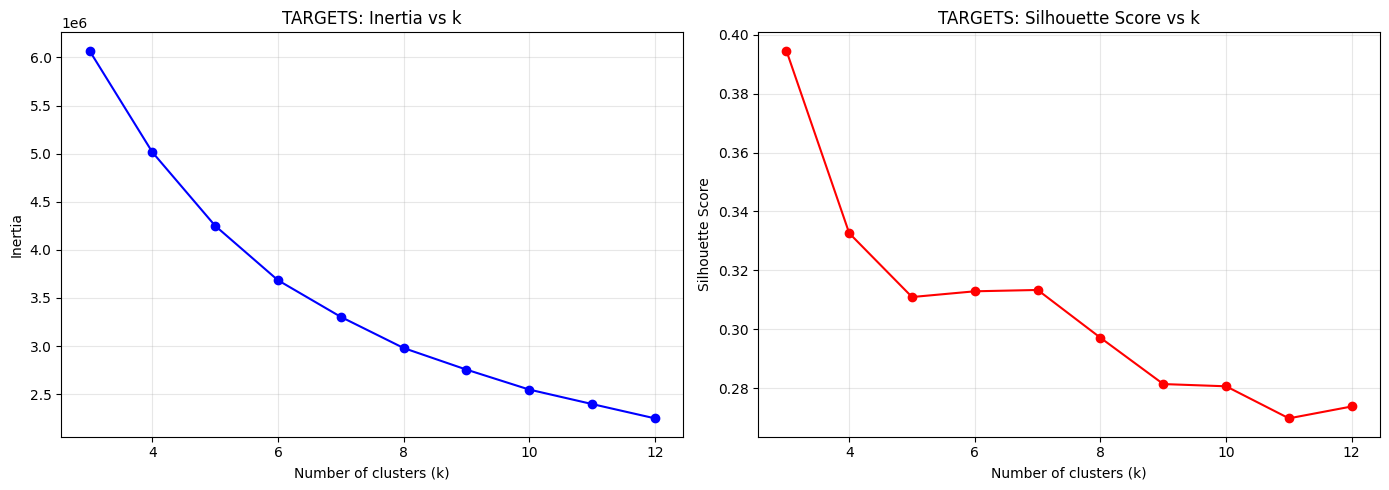

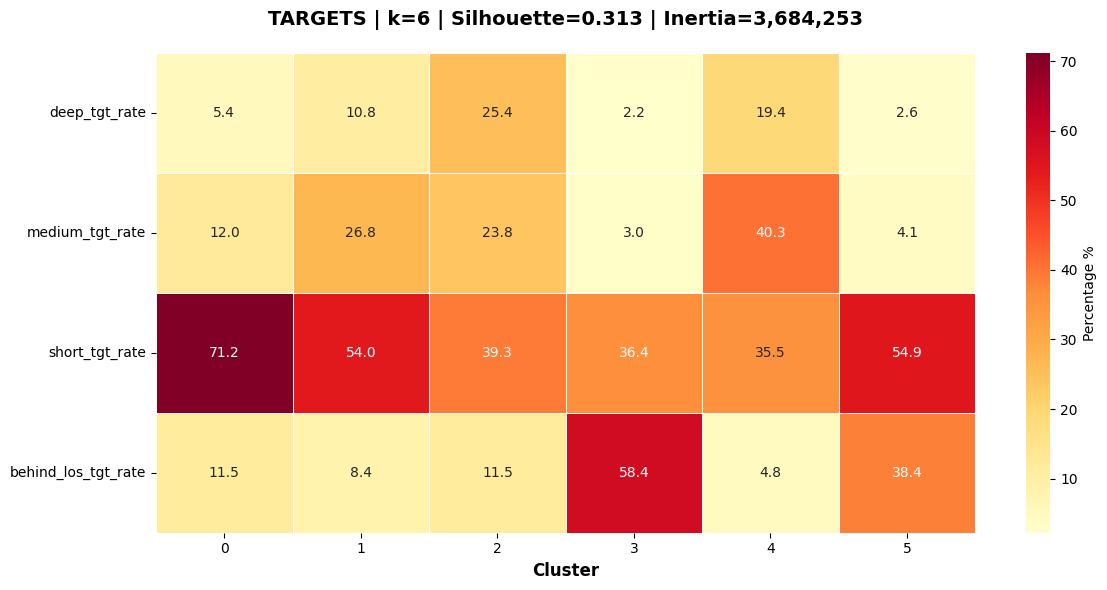


TARGETS | k=6
 cluster  count  deep_tgt_rate  medium_tgt_rate  short_tgt_rate  behind_los_tgt_rate
       0    569       5.351778        11.967934       71.222442            11.461423
       1    902      10.807656        26.835267       53.985267             8.368274
       2    511      25.438166        23.803472       39.303646            11.459674
       3    341       2.219735         2.972349       36.368129            58.440518
       4    554      19.424989        40.303061       35.460672             4.811272
       5    553       2.620840         4.130761       54.854055            38.398722

Silhouette: 0.313 | Inertia: 3,684,253


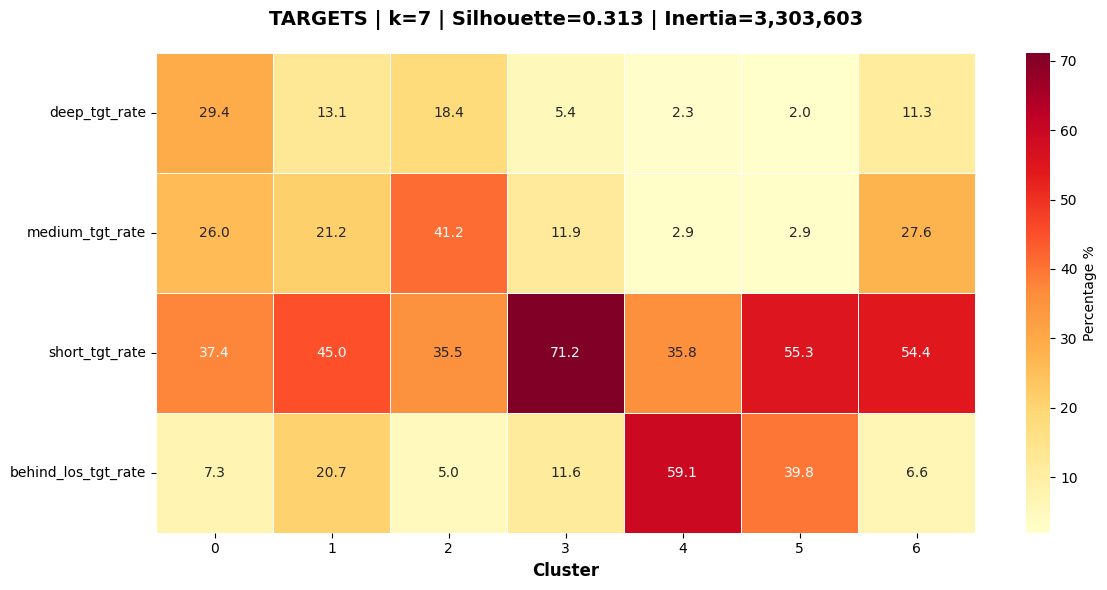


TARGETS | k=7
 cluster  count  deep_tgt_rate  medium_tgt_rate  short_tgt_rate  behind_los_tgt_rate
       0    399      29.362953        25.974140       37.412097             7.254053
       1    339      13.068787        21.225630       44.991148            20.712272
       2    490      18.372597        41.162969       35.495924             4.970141
       3    575       5.352234        11.942905       71.150086            11.559050
       4    326       2.277619         2.864176       35.786429            59.071877
       5    511       2.004226         2.898204       55.288528            39.814271
       6    790      11.341251        27.613142       54.434243             6.608349

Silhouette: 0.313 | Inertia: 3,303,603


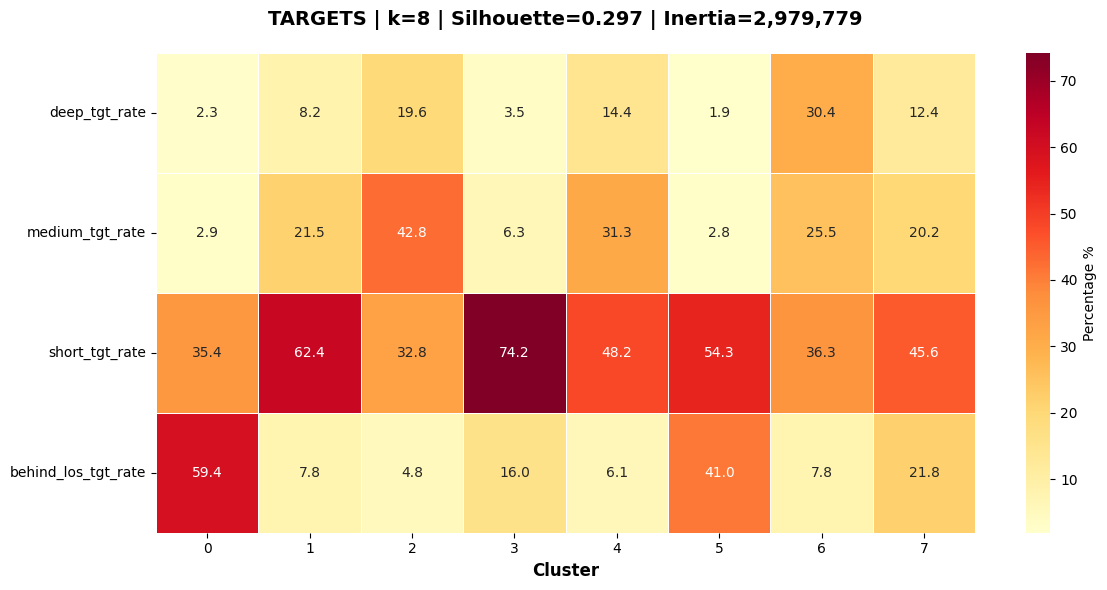


TARGETS | k=8
 cluster  count  deep_tgt_rate  medium_tgt_rate  short_tgt_rate  behind_los_tgt_rate
       0    313       2.329302         2.869010       35.357102            59.444730
       1    601       8.234042        21.532647       62.415069             7.817052
       2    365      19.560147        42.815340       32.821656             4.804109
       3    369       3.527032         6.276869       74.223542            15.978850
       4    628      14.418161        31.282455       48.178140             6.119797
       5    479       1.930706         2.801200       54.295265            40.977063
       6    357      30.400388        25.540028       36.295009             7.767992
       7    318      12.377375        20.237885       45.616356            21.767560

Silhouette: 0.297 | Inertia: 2,979,779


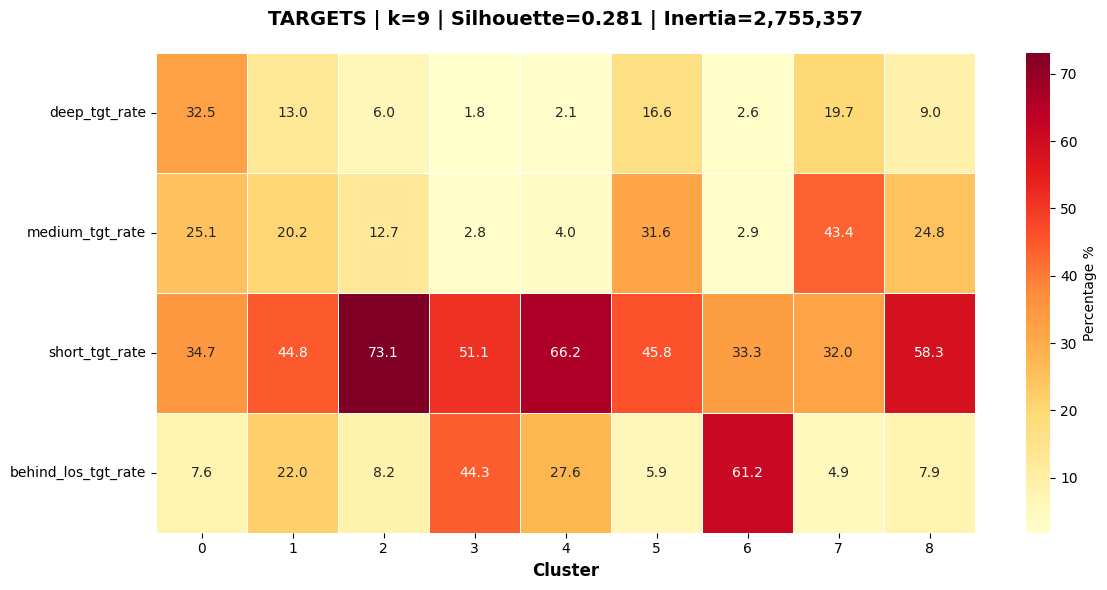


TARGETS | k=9
 cluster  count  deep_tgt_rate  medium_tgt_rate  short_tgt_rate  behind_los_tgt_rate
       0    287      32.530756        25.148431       34.722280             7.599793
       1    301      13.016422        20.230005       44.800026            21.953285
       2    376       5.972681        12.671912       73.116093             8.242177
       3    426       1.815367         2.778490       51.142764            44.267415
       4    289       2.130351         4.006144       66.220504            27.649126
       5    582      16.598069        31.613781       45.844639             5.944295
       6    254       2.583120         2.851213       33.339641            61.224862
       7    335      19.657031        43.363509       32.044196             4.935292
       8    580       9.029164        24.805880       58.264846             7.898191

Silhouette: 0.281 | Inertia: 2,755,357


In [17]:
# ============================================================================
# RUN ANALYSIS
# ============================================================================

if __name__ == "__main__":
    
    # ROUTES
    print("\n" + "="*80)
    print("ROUTE CLUSTERING ANALYSIS")
    print("="*80)
    
    run_elbow_analysis(X_rte_values, weights_route, "ROUTES")
    
    # Test specific k values for routes
    for k in [6, 7, 8, 9]:
        test_k_value(X_rte_values, weights_route, features_rte, k, "ROUTES")
    
    # TARGETS
    print("\n" + "="*80)
    print("TARGET CLUSTERING ANALYSIS")
    print("="*80)
    
    run_elbow_analysis(X_tgt_values, weights_target, "TARGETS")
    
    # Test specific k values for targets
    for k in [6, 7, 8, 9]:
        test_k_value(X_tgt_values, weights_target, features_tgt, k, "TARGETS")


In [ ]:
# IF 9 ...

# ['BT', 'ML', 'SRB', 'G', 'SMT', 'MT', 'BRB', 'DT', 'ST']